### Imports

In [2]:
import os
import cv2
import shutil
import hashlib
import numpy as np
import matplotlib.pyplot as plt

In [26]:
#Creating new folders
run_this_cell = False

if run_this_cell:
    base_path = os.path.join("D:\lung c. thesis 2d\data","merged_data")
    subfolders = ["B","M","N"]

    for folders in subfolders:
        final_fol = os.path.join(base_path,folders)
        os.makedirs(final_fol,exist_ok=True)

### Merging Dataset

In [27]:
run_this_cell = False

if run_this_cell:
    source_folders = [
        r"D:\lung c. thesis 2d\data\D - 1",
        r"D:\lung c. thesis 2d\data\D - 2",
        r"D:\lung c. thesis 2d\data\D - 3",
        r"D:\lung c. thesis 2d\data\D - 4"
    ]

    target_dir = r"D:\lung c. thesis 2d\data\merged_data"

    image_exten = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm")

    counter = 0

    for dataset_path in source_folders:
        dataset_name = os.path.basename(dataset_path)

        for root, dirs, files in os.walk(dataset_path):
            parent_folder = os.path.basename(root).lower()

            if parent_folder == "normal":
                target_class = "N"
            elif parent_folder == "benign":
                target_class = "B"
            else:
                target_class = "M"

            for file in files:
                if not file.lower().endswith(image_exten):
                    continue

                counter += 1

                src_path = os.path.join(root, file)
                _, ext = os.path.splitext(file)

                new_name = f"{dataset_name}_{counter}{ext}"
                dst_path = os.path.join(target_dir, target_class, new_name)

                shutil.copy(src_path, dst_path)


### Hashing

In [28]:
run_this_cell = False

if run_this_cell:
    base_dir = r"D:\lung c. thesis 2d\data\merged_data"
    classes = ["N", "B", "M"]

    hashes = set()
    deleted = 0

    def file_hash(path):
        h = hashlib.md5()
        with open(path, "rb") as f:
            h.update(f.read())
        return h.hexdigest()

    for cls in classes:
        folder = os.path.join(base_dir, cls)

        for file in os.listdir(folder):
            path = os.path.join(folder, file)

            if not os.path.isfile(path):
                continue

            try:
                h = file_hash(path)
            except:
                continue

            if h in hashes:
                os.remove(path)
                deleted += 1
            else:
                hashes.add(h)

    print("Duplicates deleted:", deleted)


### Experimenting contrast

In [29]:
img = cv2.imread(r"D:\lung c. thesis 2d\data\Test dataset\D - 1_1.png", cv2.IMREAD_GRAYSCALE)
print(img.shape)

(512, 512)


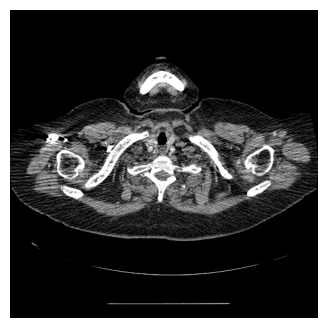

In [30]:
plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show() 

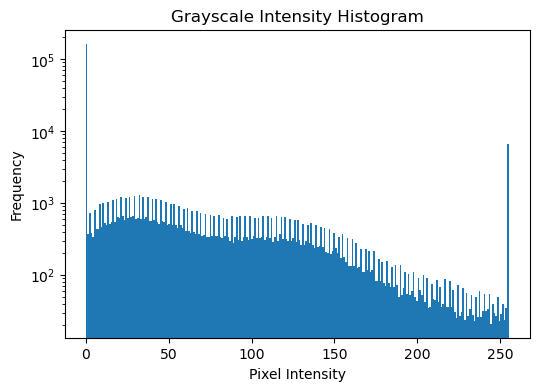

In [31]:
plt.figure(figsize=(6,4))
plt.hist(img.flatten(), bins=256, range=(0,255),log=True)
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [32]:
def stretch_intensity(img, low=-50, high=305):
    img = img.astype(np.float32)

    min_val = img.min()
    max_val = img.max()

    stretched = (img - min_val) / (max_val - min_val)
    stretched = stretched * (high - low) + low

    return stretched

def clamp_to_uint8(img):
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

stretched = stretch_intensity(img, -50, 305)
enhanced = clamp_to_uint8(stretched)


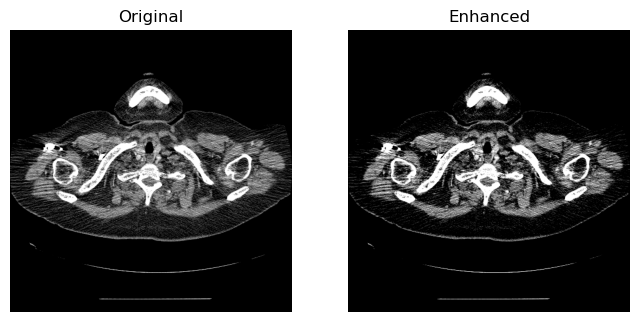

In [33]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.show()


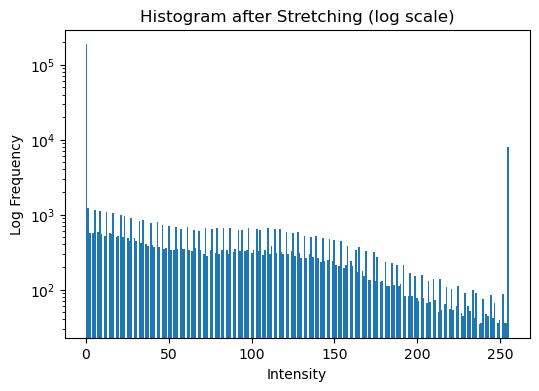

In [34]:
plt.figure(figsize=(6,4))
plt.hist(enhanced.flatten(), bins=256, range=(0,255), log=True)
plt.title("Histogram after Stretching (log scale)")
plt.xlabel("Intensity")
plt.ylabel("Log Frequency")
plt.show()


In [35]:
print("Original:", img.min(), img.max())
print("Stretched:", stretched.min(), stretched.max())
print("Enhanced:", enhanced.min(), enhanced.max())


Original: 0 255
Stretched: -50.0 305.0
Enhanced: 0 255


### Enhancement

In [ ]:
run_this_cell = False

if run_this_cell:
    target = r"D:\lung c. thesis 2d\data\merged_data"
    destination = r"D:\lung c. thesis 2d\data\Enhanced Dataset"

    low = -50
    high = 305

    for root, dirs, files in os.walk(target):

        parent_folder = os.path.basename(root)
        dest_class_dir = os.path.join(destination, parent_folder)

        for file in files:

            src_img_path = os.path.join(root, file)

            img = cv2.imread(src_img_path, cv2.IMREAD_GRAYSCALE)
            img = img.astype(np.float32)

            min_val = img.min()
            max_val = img.max()

            stretched = (img - min_val) / (max_val - min_val)
            stretched = stretched * (high - low) + low

            stretched = np.clip(stretched, 0, 255)
            stretched = stretched.astype(np.uint8)

            dst_img_path = os.path.join(dest_class_dir, file)

            cv2.imwrite(dst_img_path, stretched) #shutil copies, imwrite saves the new data

### Enhancement test. 

#### B

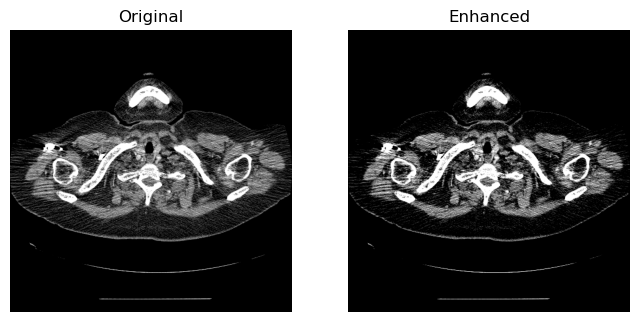

In [3]:
before = cv2.imread(r"D:\lung c. thesis 2d\data\merged_data\B\D - 1_1.png",cv2.IMREAD_GRAYSCALE)
after = cv2.imread(r"D:\lung c. thesis 2d\data\Enhanced Dataset\B\D - 1_1.png",cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(before, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(after, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.show()

#### M

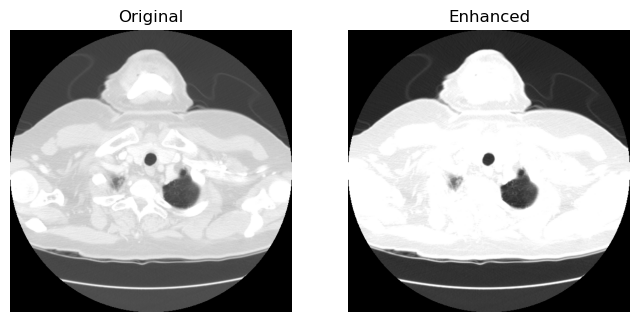

In [4]:
before = cv2.imread(r"D:\lung c. thesis 2d\data\merged_data\M\D - 1_204.png",cv2.IMREAD_GRAYSCALE)
after = cv2.imread(r"D:\lung c. thesis 2d\data\Enhanced Dataset\M\D - 1_204.png",cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(before, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(after, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.show()

#### N

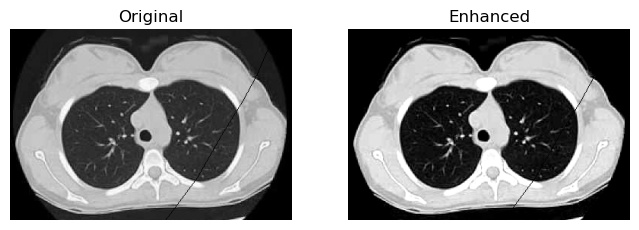

In [5]:
before = cv2.imread(r"D:\lung c. thesis 2d\data\merged_data\N\D - 2_2238.png",cv2.IMREAD_GRAYSCALE)
after = cv2.imread(r"D:\lung c. thesis 2d\data\Enhanced Dataset\N\D - 2_2238.png",cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(before, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(after, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.show()

In [37]:
'''
IN PAPER:

1. Benign = 1105
2. Malignant = 2277
3. Normal = 470
'''

'''
IN OURS:

1. Benign = 1105
2. Malignant = 2279
3. Normal = 471
'''

'\nIN OURS:\n\n1. Benign = 1105\n2. Malignant = 2279\n3. Normal = 471\n'